<a href="https://colab.research.google.com/github/mochamadx5/PCVK26_11_MochamadReza/blob/main/P6_Praktikum_11_Mochamad_Reza_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
NAMA = 'Mochamad Reza Firdaus'
NIM = '244107020104'
print(NAMA, NIM)

Mochamad Reza Firdaus 244107020104


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Hasil Image Sharpen:


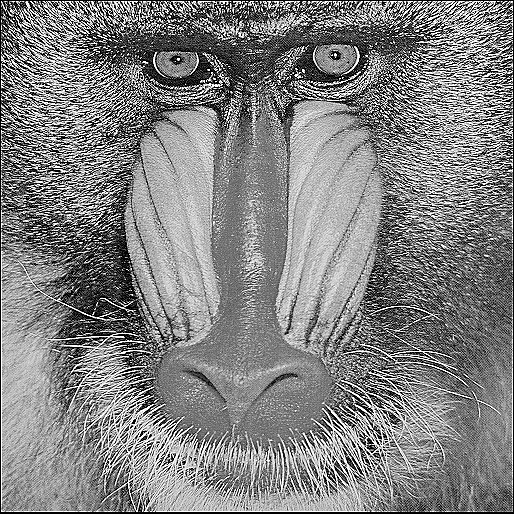

Hasil Image Emboss:


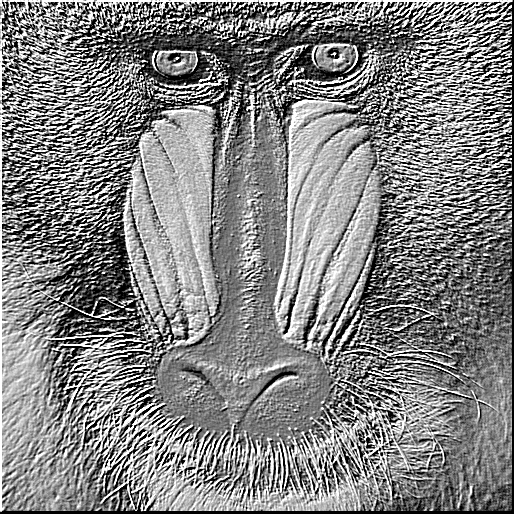

Hasil Left sobel edge detection:


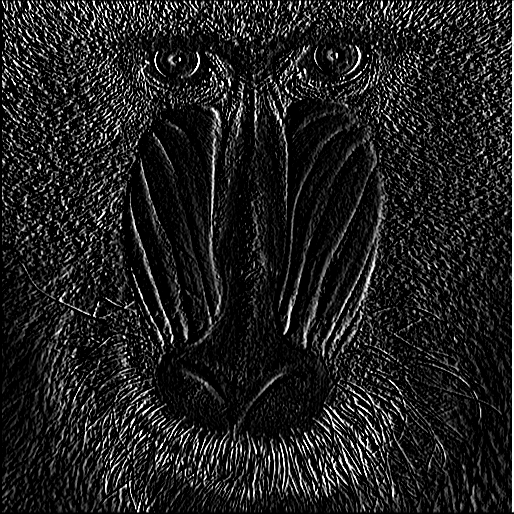

Hasil Canny Edge Detection:


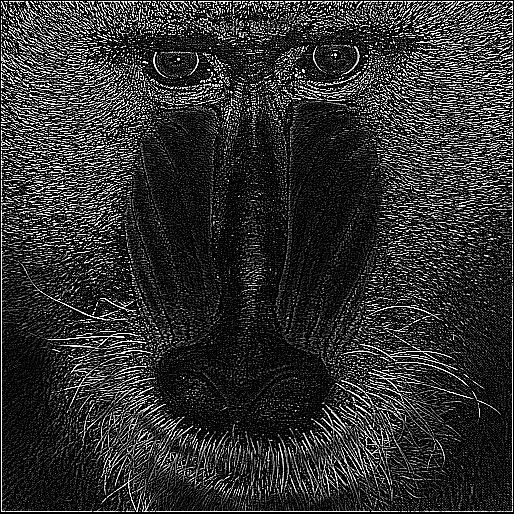

Hasil Gaussian Blur:


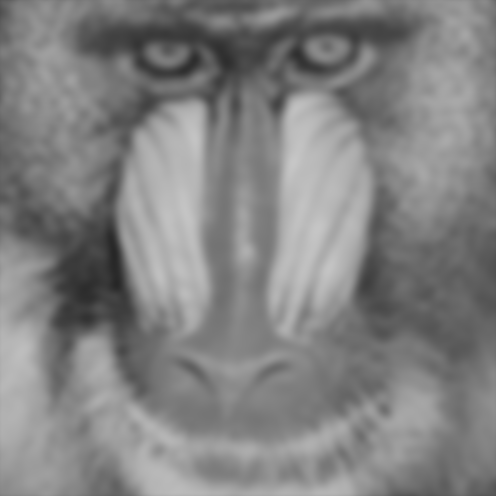

In [40]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

def convolution2d(image, kernel, stride, padding):
    # Ubah tipe data gambar ke float32 untuk menghindari overflow/underflow
    img_float = image.astype(np.float32)

    # Terapkan zero-padding di sekeliling gambar
    padded_image = np.pad(img_float, padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Hitung ukuran dimensi output
    out_h = (img_h - k_h + 2 * padding) // stride + 1
    out_w = (img_w - k_w + 2 * padding) // stride + 1

    # Inisialisasi matriks output
    output = np.zeros((out_h, out_w), dtype=np.float32)

    # Proses konvolusi 2D
    for i in range(out_h):
        for j in range(out_w):
            start_i = i * stride
            end_i = start_i + k_h
            start_j = j * stride
            end_j = start_j + k_w

            # Ambil region of interest (ROI) sesuai ukuran kernel
            region = padded_image[start_i:end_i, start_j:end_j]

            # Operasi perkalian matriks dan penjumlahan
            output[i, j] = np.sum(region * kernel)

    # Batasi nilai piksel agar berada di rentang [0, 255] lalu ubah ke uint8
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

# Memuat gambar (Pastikan path file Anda benar dan Google Drive sudah dimount)
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Image Sharpen
kernel_sharpen = np.array([[-0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1, -0]])
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)
print("Hasil Image Sharpen:")
cv2_imshow(res_sharpen)

# Image Emboss
kernel_emboss = np.array([[-2, -1,  0],
                           [-1,  1,  1],
                           [ 0,  1,  2]])
res_emboss = convolution2d(image=img_gray, kernel=kernel_emboss, stride=1, padding=2)
print("Hasil Image Emboss:")
cv2_imshow(res_emboss)

# Image left sobel edge detection
kernel_sobel = np.array([[1,  0, -1],
                          [2,  0, -2],
                          [1,  0, -1]])
res_sobel = convolution2d(image=img_gray, kernel=kernel_sobel, stride=1, padding=2)
print("Hasil Left sobel edge detection:")
cv2_imshow(res_sobel)

# image Canny Edge Detection (Diperbaiki tanda komanya)
kernel_canny = np.array([[-1, -1, -1],
                          [-1,  8, -1],
                          [-1, -1, -1]])
res_canny = convolution2d(image=img_gray, kernel=kernel_canny, stride=1, padding=2)
print("Hasil Canny Edge Detection:")
cv2_imshow(res_canny)

# Image Gaussian Blur
kernel_size = 21  # Ukuran kernel Gaussian
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
res_gaussian = convolution2d(image=img_gray, kernel=gauss_kernel, stride=1, padding=2)
print("Hasil Gaussian Blur:")
cv2_imshow(res_gaussian)

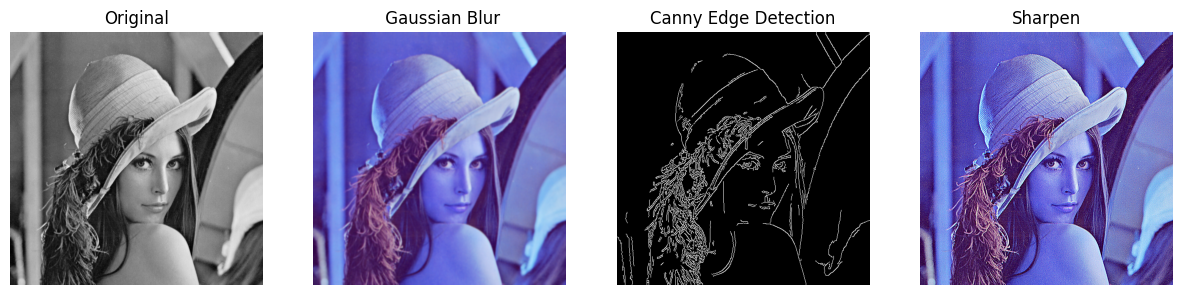

In [47]:
# FILTER LIBRARY DAN FILTER MODERN

def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
      if len(img.shape) == 2:  # grayscale
        plt.subplot(1, len(images), i+1)
        plt.imshow(img, cmap='gray')
      else : # color
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
      plt.title(title)
      plt.axis('off')
    plt.show()
img = cv.imread('/content/drive/MyDrive/PCVK/lena.png')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1, 0], [-1,5,-1], [0,-1,0]])
sharpen = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img_gray, blur, edges, sharpen],
                  ['Original', ' Gaussian Blur', 'Canny Edge Detection', 'Sharpen'])

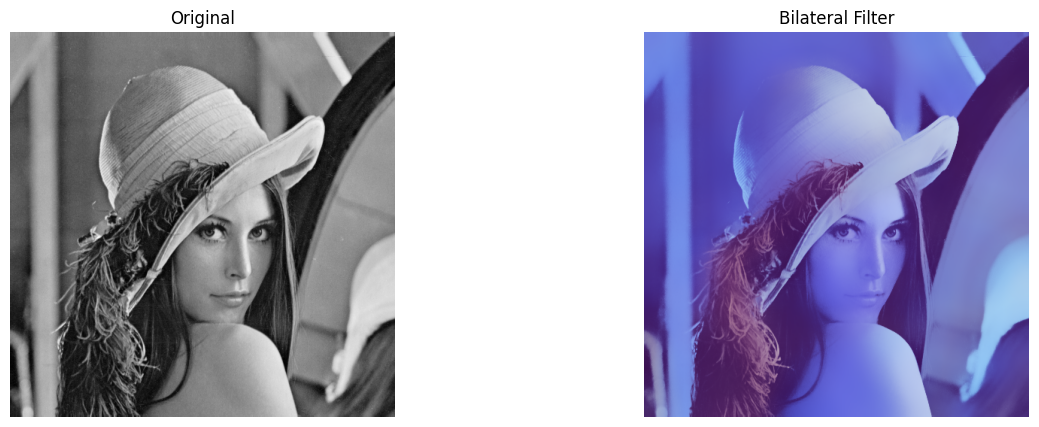

In [49]:
# filter modern dari OpenCV

# bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

#edge preserving filter
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img_gray, bilateral], ['Original', 'Bilateral Filter', 'Edge Preserving Filter'])